# Hand Counting (dactylonomy) Detector
*Written by Ethan Arnold*

In this notebook, I will use a Convolutional Neural Network to detect which number is represented by an image of a hand gesture.

I have closely followed [this](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) PyTorch tutorial.

## Setup Dataset

### Import Libraries

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

### Load dataset from *HDF5* files

The training and testing data has been pre-split into 2 files 1080/120, respectively:

In [2]:
training_file = h5py.File('./data/Signs_Data_Training.h5', 'r')
testing_file = h5py.File('./data/Signs_Data_Testing.h5', 'r')

### Prepare Dataset for Computation

The shape of the images in the dataset are 3x64x64, as they are represented by 3-channel (RGB) unsigned 8-bit integers.

First we will read them in as `numpy` arrays:

In [3]:
training_data = torch.from_numpy(np.array(training_file['train_set_x']))
training_labels = torch.from_numpy(np.array(training_file['train_set_y']))
testing_data = torch.from_numpy(np.array(testing_file['test_set_x']))
testing_labels = torch.from_numpy(np.array(testing_file['test_set_y']))

Machine Learning algorithms use floats because of their precision, thus I will convert the image data (but not labels) into normalized floats:

In [4]:
training_data = training_data.float() / 255.0
testing_data = testing_data.float() / 255.0

Now, we must permute the data, as PyTorch reads data as `[channel][row][col]`:

In [5]:
training_data = training_data.permute(0, 3, 1, 2)
testing_data = testing_data.permute(0, 3, 1, 2)

PyTorch recieves data in batches, so we will encapsulate our dataset in a `DataLoader` object:

In [6]:
batch_size = 4

training_loader = DataLoader(
    TensorDataset(training_data, training_labels), batch_size=batch_size
)
testing_loader = DataLoader(
    TensorDataset(testing_data, testing_labels), batch_size=batch_size
)

### Sample Images

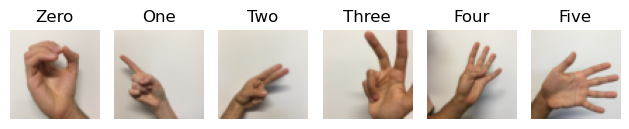

In [7]:
# acquire set of first instance of each class of hand gesture
sample_figures = [
    {'image': training_data[(training_labels == 0).nonzero(as_tuple=True)[0][0]].permute(1, 2, 0), 'title': 'Zero'},
    {'image': training_data[(training_labels == 1).nonzero(as_tuple=True)[0][0]].permute(1, 2, 0), 'title': 'One'},
    {'image': training_data[(training_labels == 2).nonzero(as_tuple=True)[0][0]].permute(1, 2, 0), 'title': 'Two'},
    {'image': training_data[(training_labels == 3).nonzero(as_tuple=True)[0][0]].permute(1, 2, 0), 'title': 'Three'},
    {'image': training_data[(training_labels == 4).nonzero(as_tuple=True)[0][0]].permute(1, 2, 0), 'title': 'Four'},
    {'image': training_data[(training_labels == 5).nonzero(as_tuple=True)[0][0]].permute(1, 2, 0), 'title': 'Five'}
]

# print each class of hand gesture
fig, axs = plt.subplots(1, len(sample_figures))
for ax, sample_figure in zip(axs, sample_figures):
    ax.imshow(sample_figure['image'])
    ax.set_title(sample_figure['title'])
    ax.axis("off")
plt.tight_layout()
plt.show()

### Create Convolutional Neural Network

The CNN will have the following layers:
1. 2D Convolution: 3 layers in, 6 layers out, 5x5 kernel
2. 2D Pooling: 2x2 kernel, 2 stride
3. 2D Convolution: 6 layers in, 12 layers out, 5x5 kernel
4. Flatten to linear array
5. Linear layer: 8112 in, 120 out
6. Linear layer: 120 in, 80 out
7. Linear layer: 80 in, 6 out

In [8]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 12, 5)
        self.fc1 = nn.Linear(12 * 13 * 13, 120)
        self.fc2 = nn.Linear(120, 80)
        self.fc3 = nn.Linear(80, 6) # 6 hand gesture classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # linearize image data
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

cnn = ConvNeuralNetwork()

### Choose Optimizer and Loss Functions

For calculating loss, I have chose a *Categorical Cross-Entropy Loss* function because we are categorizing images into *multiple* classes.

I have opted for *Stochastic Gradient Descent* instead of the conventional *Gradient Descent* algorithm as it does not need to consider entire dataset each iteration, saving time.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=0.001, momentum=0.9)

## Train Model

I train the model over 4 epochs:

In [10]:
epochs = 4

for epoch in range(epochs):

    for data in training_loader:
        inputs, labels = data
        
        optimizer.zero_grad()

        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Completed epoch {epoch+1}/{epochs}\r", end="")
print("\nCompleted training")

Completed epoch 4/4
Completed training


## Test Model